### Notebook 3: Dimensionality Reduction and Vulnerability Classification

This notebook applies Principal Component Analysis (PCA) and clustering techniques to identify latent neighbourhood vulnerability structures within Toronto neighbourhoods.

The objective is to reduce redundancy among highly correlated indicators and develop an evidence-based neighbourhood vulnerability classification framework.

In [11]:
import pandas as pd

df = pd.read_csv(
    "toronto_neighbourhood_analysis_v2.csv",
    index_col=0)

print(df.shape)

df.head()

(140, 12)


,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,21.3,19995,26365,1720,6550,4380,2220,34.7,55.4,50.0,9.8,1650
Agincourt South-Malvern West,22.6,15095,20155,2250,4035,4210,1795,38.2,59.0,53.2,9.8,1360
Alderwood,8.2,3970,2490,950,2005,1660,540,21.7,66.5,62.4,6.1,670
Annex,18.3,8270,7270,9870,1585,9135,2420,40.4,70.6,65.8,6.7,895
Banbury-Don Mills,13.7,13195,12700,4735,2295,6500,2115,33.4,59.9,55.6,7.2,1255


### Standardization

The indicators are measured on different scales. Standardization is performed to ensure that all variables contribute equally to the PCA model.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns,
    index=df.index)

scaled_df.head()

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Agincourt North,0.227208,1.789721,1.977775,-0.678964,2.056964,0.184792,0.500212,-0.053820,-1.502679,-1.428182,0.791877,0.850533
Agincourt South-Malvern West,0.392549,0.988995,1.231874,-0.502192,0.715039,0.128795,0.074910,0.452355,-0.911323,-0.935288,0.791877,0.409769
Alderwood,-1.438922,-0.828979,-0.889921,-0.935783,-0.368105,-0.711170,-1.180981,-1.933896,0.320670,0.481782,-1.166081,-0.638944
Annex,-0.154349,-0.126301,-0.315781,2.039321,-0.592204,1.751080,0.700354,0.770521,0.994160,1.005481,-0.848574,-0.296973
Banbury-Don Mills,-0.739402,0.678510,0.336432,0.326635,-0.213370,0.883116,0.395138,-0.241827,-0.763484,-0.565618,-0.583985,0.250182


In [13]:
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
LIM_AT,140.0,-3.647876e-16,1.003591,-1.909508,-0.688527,-0.122552,0.564249,3.305095
Immigrants,140.0,6.344132e-17,1.003591,-1.184403,-0.722556,-0.251721,0.373335,3.594622
Visible_Minority,140.0,6.344132e-17,1.003591,-1.056878,-0.752542,-0.333498,0.313010,3.676772
Renters,140.0,-5.075305e-17,1.003591,-1.159250,-0.603502,-0.174497,0.194473,6.728780
No_Diploma,140.0,-9.198991e-17,1.003591,-1.192469,-0.678242,-0.286736,0.406903,3.663006
Bachelors_Degree,140.0,1.268826e-17,1.003591,-1.111389,-0.581470,-0.184957,0.186439,7.728005
Core_Housing_Need,140.0,3.172066e-17,1.003591,-1.606283,-0.753178,-0.287847,0.567760,3.617425
Unaffordable_Housing,140.0,9.738242e-16,1.003591,-2.541305,-0.578072,0.076339,0.499357,3.098924
Participation_Rate,140.0,-1.801733e-15,1.003591,-2.028329,-0.767590,-0.155700,0.751868,3.622411
Employment_Rate,140.0,1.674851e-15,1.003591,-1.844061,-0.708095,-0.111231,0.774437,3.608577


In [14]:
from sklearn.decomposition import PCA

pca = PCA()

pca.fit(scaled_df)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [15]:
explained_variance = pca.explained_variance_ratio_

explained_variance

array([4.91885094e-01, 2.58883249e-01, 1.35068372e-01, 4.65874961e-02,
       2.57623670e-02, 1.88679311e-02, 8.43162942e-03, 6.44468784e-03,
       4.22891315e-03, 2.78628839e-03, 1.03997127e-03, 1.40005556e-05])

In [16]:
import numpy as np

np.cumsum(explained_variance)

array([0.49188509, 0.75076834, 0.88583672, 0.93242421, 0.95818658,
       0.97705451, 0.98548614, 0.99193083, 0.99615974, 0.99894603,
       0.999986  , 1.        ])

### Interpretation of PCA Results

Principal Component Analysis (PCA) was applied to reduce redundancy among the selected vulnerability indicators and identify the underlying dimensions of neighbourhood vulnerability.

The first principal component (PC1) explained approximately 49.2% of the total variance in the dataset, indicating the presence of a dominant latent vulnerability dimension shared across multiple indicators.

The first two principal components collectively explained approximately 75.1% of the total variance, exceeding the commonly used 70% threshold for dimensionality reduction in social science research. When the first three principal components were retained, the cumulative explained variance increased to approximately 88.6%.

These results demonstrate that a substantial proportion of the information contained within the original twelve indicators can be represented using a much smaller number of principal components. Consequently, PCA provides an effective approach for reducing multicollinearity while preserving the majority of the socioeconomic information present in the dataset.

Based on the cumulative explained variance results, the first three principal components will be retained for subsequent interpretation, vulnerability score construction, and neighbourhood clustering analyses.

### Variance Retained by Principal Components

| Components Retained | Cumulative Variance Explained |
|--------------------|-------------------------------|
| 1 Component | 49.2% |
| 2 Components | 75.1% |
| 3 Components | 88.6% |
| 4 Components | 93.2% |

The first three principal components were selected because they retain nearly 89% of the total dataset variance while reducing the dimensionality of the original indicator set from twelve variables to three latent dimensions.

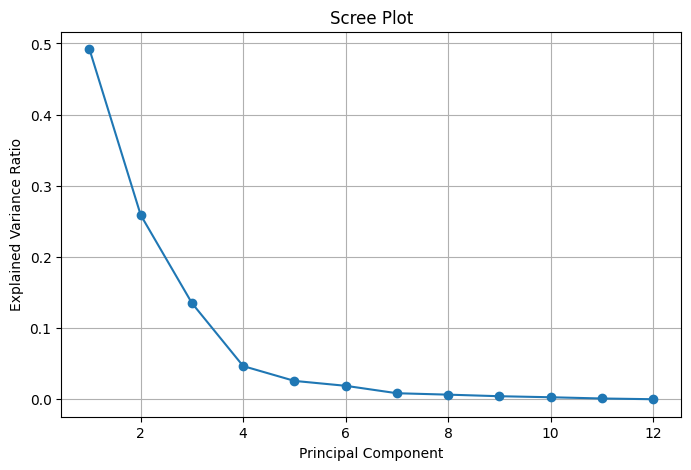

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o")

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Scree Plot")

plt.grid(True)

plt.show()

### Scree Plot Interpretation

The scree plot demonstrates a clear decline in explained variance after the third principal component, indicating that the majority of the dataset variability is captured by the first three components.

The first principal component explains approximately 49.2% of the total variance, while the first three components collectively explain approximately 88.6% of the total variance. Beyond the third component, each additional component contributes only a small amount of explanatory power.

Based on the scree plot and cumulative variance results, three principal components are retained for further analysis. This reduces the dimensionality of the original twelve indicators while preserving the majority of the socioeconomic information contained in the dataset.

In [18]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(df.columns))],
    index=df.columns)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
LIM_AT,0.270804,-0.094542,0.538964,-0.134795,-0.058487,0.023470,0.734808,-0.101764,0.145048,-0.116918,0.141564,-0.007455
Immigrants,0.373515,0.107178,-0.222919,0.193748,0.275749,0.105044,-0.053743,-0.201053,-0.215030,-0.101973,0.758001,0.013527
Visible_Minority,0.374051,0.063192,-0.194827,0.173558,0.304143,0.397468,0.252888,-0.016055,-0.178552,0.507053,-0.429311,-0.005154
Renters,0.193070,0.447541,0.184717,0.063197,-0.480836,-0.219603,-0.083929,0.284053,-0.005980,0.552748,0.227046,0.006467
No_Diploma,0.329238,-0.072547,-0.334465,-0.449450,0.100902,-0.175473,0.124481,0.683861,-0.077639,-0.205381,-0.007137,-0.008572
Bachelors_Degree,0.132083,0.474414,-0.062572,0.547856,-0.112487,0.116807,0.087443,0.210959,0.223871,-0.529245,-0.211177,-0.012704
Core_Housing_Need,0.359090,0.213565,0.033324,-0.224347,-0.220788,-0.289282,-0.116269,-0.440085,-0.514042,-0.254524,-0.324572,-0.003145
Unaffordable_Housing,0.221315,0.120720,0.571136,-0.016144,0.595610,-0.169044,-0.423627,0.134434,0.135520,-0.002525,-0.103630,0.004251
Participation_Rate,-0.206681,0.444393,0.042337,-0.411458,0.067713,0.393612,-0.008996,-0.033036,-0.015262,-0.044854,0.069265,-0.648827
Employment_Rate,-0.229323,0.442145,-0.008071,-0.340972,0.124585,0.225028,0.078211,-0.044176,-0.001600,-0.027056,0.035146,0.747926


### Principal Component Loadings Interpretation

The component loadings indicate the contribution of each indicator to the principal components.

#### Principal Component 1 (PC1): Socioeconomic Vulnerability

PC1 exhibits strong positive loadings for:

- Immigrants
- Visible Minority
- Core Housing Need
- Lone Parent Families
- LIM_AT
- No Diploma

and negative loadings for:

- Employment Rate
- Participation Rate

These patterns suggest that PC1 represents a broad dimension of socioeconomic vulnerability. Neighbourhoods with higher PC1 scores tend to experience greater housing stress, educational disadvantage, demographic vulnerability, and lower labour market outcomes.

#### Principal Component 2 (PC2): Labour Market and Educational Advantage

PC2 is strongly associated with:

- Bachelors Degree
- Renters
- Participation Rate
- Employment Rate

This component appears to capture neighbourhoods characterized by higher educational attainment and stronger labour market participation.

#### Principal Component 3 (PC3): Housing Affordability Pressure

PC3 shows its strongest positive loadings for:

- LIM_AT
- Unaffordable Housing

and negative loadings for:

- No Diploma
- Lone Parent Families

This component appears to reflect housing affordability challenges and income-related pressures that are distinct from the broader vulnerability dimension captured by PC1.

Overall, the three retained principal components represent complementary dimensions of neighbourhood vulnerability and socioeconomic conditions across Toronto neighbourhoods.

In [19]:
loadings[["PC1", "PC2", "PC3"]].sort_values(
    by="PC1",
    ascending=False)

,PC1,PC2,PC3
Visible_Minority,0.374051,0.063192,-0.194827
Immigrants,0.373515,0.107178,-0.222919
Lone_Parent_Families,0.363687,0.030531,-0.291463
Core_Housing_Need,0.359090,0.213565,0.033324
No_Diploma,0.329238,-0.072547,-0.334465
Unemployment_Rate,0.280388,-0.301435,0.240520
LIM_AT,0.270804,-0.094542,0.538964
Unaffordable_Housing,0.221315,0.120720,0.571136
Renters,0.193070,0.447541,0.184717
Bachelors_Degree,0.132083,0.474414,-0.062572


### Principal Component Interpretation

The PCA loading matrix was examined to determine the variables contributing most strongly to each retained component.

#### Principal Component 1 (PC1): Neighbourhood Vulnerability

PC1 is dominated by:

- Visible Minority (0.374)
- Immigrants (0.374)
- Lone Parent Families (0.364)
- Core Housing Need (0.359)
- No Diploma (0.329)
- Unemployment Rate (0.280)
- LIM_AT (0.271)

and negatively associated with:

- Employment Rate (-0.229)
- Participation Rate (-0.207)

These loadings suggest that PC1 represents a general neighbourhood vulnerability dimension characterized by demographic concentration, housing stress, educational disadvantage, and weaker labour market outcomes. (Vulnerability)

#### Principal Component 2 (PC2): Educational and Labour Market Advantage

PC2 is most strongly associated with:

- Bachelors Degree (0.474)
- Renters (0.448)
- Participation Rate (0.444)
- Employment Rate (0.442)

This component appears to capture neighbourhoods characterized by higher educational attainment and stronger labour force participation.(Education & Workforce Advantage)

#### Principal Component 3 (PC3): Housing Affordability Pressure

PC3 is dominated by:

- Unaffordable Housing (0.571)
- LIM_AT (0.539)

and negatively associated with:

- No Diploma (-0.334)
- Lone Parent Families (-0.291)

This component reflects housing affordability pressures and income-related challenges that are distinct from the broader vulnerability dimension captured by PC1.

Overall, the first three principal components capture the major socioeconomic dimensions underlying neighbourhood vulnerability in Toronto.(Housing Affordibility)

### Principal Component Scores

Neighbourhood scores are calculated for the retained principal components. These scores provide a reduced-dimensional representation of the original indicators and will be used as inputs for clustering analysis.

In [21]:
from sklearn.decomposition import PCA

pca_final = PCA(n_components=3)

principal_components = pca_final.fit_transform(scaled_df)

pca_scores = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2", "PC3"],
    index=df.index)

pca_scores.head()

,PC1,PC2,PC3
Agincourt North,3.377519,-1.481750,-1.610389
Agincourt South-Malvern West,1.992874,-1.042893,-0.288028
Alderwood,-3.016146,-0.536698,-1.651011
Annex,-0.137021,3.143159,0.851532
Banbury-Don Mills,0.591624,0.394004,-0.904954


In [22]:
print(pca_scores.shape)

(140, 3)


### Principal Component Scores interpration

The original 12 socioeconomic indicators were transformed into three principal components representing the major dimensions of neighbourhood variation.

The resulting PCA score matrix contains:

- 140 neighbourhood observations
- 3 principal components
- Approximately 88.6% of total variance retained

These component scores provide a compact representation of neighbourhood vulnerability and will serve as inputs for clustering analysis.

### K-Means Clustering

The Elbow Method is used to identify an appropriate number of clusters for grouping neighbourhoods with similar vulnerability profiles.

In [24]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    kmeans.fit(pca_scores)

    inertia.append(kmeans.inertia_)

inertia

[1488.2056815655305,
 899.8812278943971,
 700.7743899188201,
 532.3553302009592,
 464.1258350904809,
 401.8785789388125,
 343.27210492871285,
 291.25746581604466,
 267.4082274551769,
 246.59364196222654]

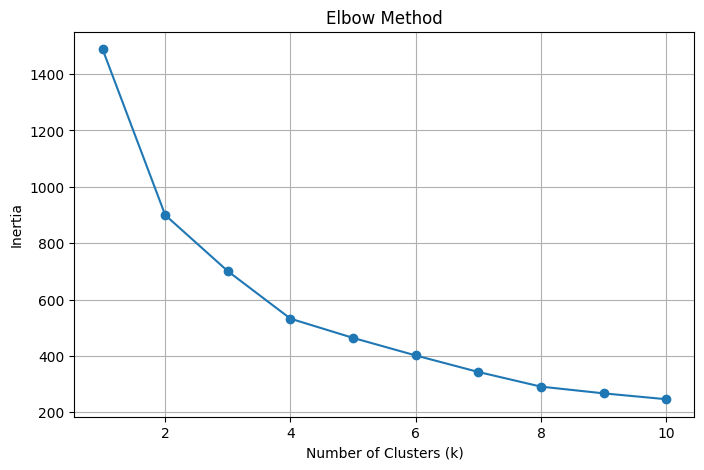

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Elbow Method Interpretation

The elbow plot shows a substantial reduction in inertia between one and four clusters, after which the rate of improvement begins to level off.

The elbow occurs at approximately k = 4, indicating that four clusters provide a reasonable balance between model simplicity and within-cluster homogeneity.

Therefore, four neighbourhood groups are retained for the final clustering analysis.

### Final K-Means Clustering

Neighbourhoods are grouped into four clusters using the first three principal components. These clusters represent neighbourhoods with similar socioeconomic vulnerability profiles.

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10)

pca_scores["Cluster"] = kmeans.fit_predict(pca_scores)

pca_scores.head()

,PC1,PC2,PC3,Cluster
Agincourt North,3.377519,-1.481750,-1.610389,1
Agincourt South-Malvern West,1.992874,-1.042893,-0.288028,0
Alderwood,-3.016146,-0.536698,-1.651011,2
Annex,-0.137021,3.143159,0.851532,3
Banbury-Don Mills,0.591624,0.394004,-0.904954,0


In [27]:
pca_scores["Cluster"].value_counts().sort_index()

Cluster
0    49
1    18
2    62
3    11
Name: count, dtype: int64

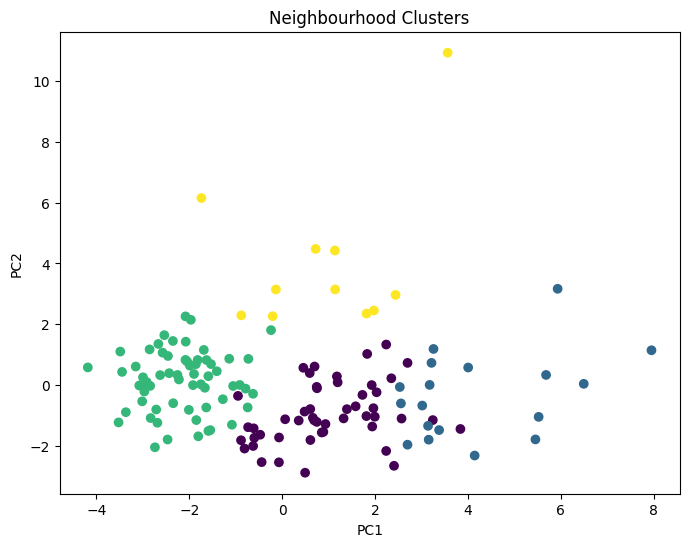

In [28]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    pca_scores["PC1"],
    pca_scores["PC2"],
    c=pca_scores["Cluster"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Neighbourhood Clusters")

plt.show()

In [29]:
cluster_summary = df.copy()

cluster_summary["Cluster"] = pca_scores["Cluster"]

cluster_summary.groupby("Cluster").mean().round(2)

,LIM_AT,Immigrants,Visible_Minority,Renters,No_Diploma,Bachelors_Degree,Core_Housing_Need,Unaffordable_Housing,Participation_Rate,Employment_Rate,Unemployment_Rate,Lone_Parent_Families
Cluster,,,,,,,,,,,,
0,25.40,9681.43,10995.10,3564.90,2776.84,2951.94,1870.31,38.80,60.56,54.67,9.73,1156.22
1,23.03,20400.28,26368.06,4639.72,6312.22,5023.61,2999.72,36.55,58.66,52.79,10.04,2339.17
2,13.67,4687.50,3900.16,2391.53,1592.50,3086.77,980.56,30.80,67.73,63.05,6.94,645.24
3,20.48,12162.27,11879.09,10847.73,2624.09,9837.27,3125.91,40.14,74.03,69.05,6.81,1262.73


### Final Cluster Interpretation
Cluster 1 — High Vulnerability (18 neighbourhoods)

Highest levels of:

Immigrants (20,400)
Visible Minority population (26,368)
No Diploma (6,312)
Lone Parent Families (2,339)
Core Housing Need (3,000)
Unemployment Rate (10.04%)

Lowest:

Employment Rate (52.79%)

Interpretation:
This cluster represents the most vulnerable neighbourhoods, characterized by demographic concentration, lower educational attainment, higher housing need, and weaker labour market outcomes.

Cluster 2 — Low Vulnerability (62 neighbourhoods)

Lowest levels of:

LIM_AT (13.67%)
Immigrants (4,688)
Visible Minority population (3,900)
Core Housing Need (981)
Lone Parent Families (645)

Highest:

Employment Rate (63.05%)
Strong labour market participation
Low unemployment (6.94%)

Interpretation:
These neighbourhoods exhibit the most favourable socioeconomic conditions and the lowest overall vulnerability.

Cluster 3 — Affluent Urban Core (11 neighbourhoods)

Highest levels of:

Renters (10,848)
Bachelor's Degree (9,837)
Participation Rate (74.03%)
Employment Rate (69.05%)

Lowest:

Unemployment Rate (6.81%)

Interpretation:
This cluster reflects highly educated, urban-core neighbourhoods with strong labour market outcomes and large renter populations.

Cluster 0 — Moderate Vulnerability (49 neighbourhoods)

Characteristics fall between Clusters 1 and 2.

Interpretation:
Neighbourhoods in this cluster experience moderate socioeconomic challenges but do not exhibit the severe vulnerability observed in Cluster 1.

### Conclusions

This notebook applied Principal Component Analysis (PCA) and K-Means clustering to identify patterns of socioeconomic vulnerability across Toronto neighbourhoods.

PCA reduced the original 12 indicators to three principal components while retaining approximately 88.6% of the total variance. The first component captured overall vulnerability, the second represented educational and labour market advantage, and the third reflected housing affordability pressures.

Using the PCA scores, K-Means clustering identified four distinct neighbourhood groups:

- Cluster 0: Moderate Vulnerability
- Cluster 1: High Vulnerability
- Cluster 2: Low Vulnerability
- Cluster 3: Affluent Urban Core

The clustering results demonstrate that Toronto neighbourhoods differ substantially in demographic composition, educational attainment, housing conditions, and labour market outcomes.

The final clustering framework provides a practical approach for understanding neighbourhood vulnerability and can support future policy development, planning initiatives, and targeted resource allocation.

In [30]:
final_results = df.copy()

final_results["Cluster"] = pca_scores["Cluster"]

final_results.to_csv(
    "toronto_neighbourhood_clusters.csv",
    index=True)

print("Clustering results exported successfully.")

Clustering results exported successfully.
